In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
rng = np.random.default_rng(seed=42)

In [52]:
fp = "mnist.csv"
df = pd.read_csv(fp)
df.reset_index(drop=True, inplace=True)
df.describe()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,42000.000000,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,...,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.0,42000.0,42000.0,42000.0
mean,4.456643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.219286,0.117095,0.059024,0.02019,0.017238,0.002857,0.0,0.0,0.0,0.0
std,2.887730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.312890,4.633819,3.274488,1.75987,1.894498,0.414264,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.00000,254.000000,62.000000,0.0,0.0,0.0,0.0


In [53]:
df.head(3)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [54]:
df.to_numpy()[0:3, ]

array([[1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0]], shape=(3, 785))

In [65]:
ds = df.to_numpy()
ds = rng.permutation(ds, axis=0)        # Perturb matrix rows

assert np.isnan(ds).sum() == 0      # No NaNs!!!

def normalize(arr):
    return (arr - np.min(arr)) / (np.max(arr) - np.min(arr))

m, n = ds.shape
x_train = normalize(ds[0:int(0.75*m),1: ])
x_test = normalize(ds[int(0.75*m): ,1: ])      # end=start as Python splits exclusive of the end: [,) 

y_train = ds[0:int(0.75*m),0]
y_test = ds[int(0.75*m): ,0]

print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

(31500, 784) (31500,) (10500, 784) (10500,)


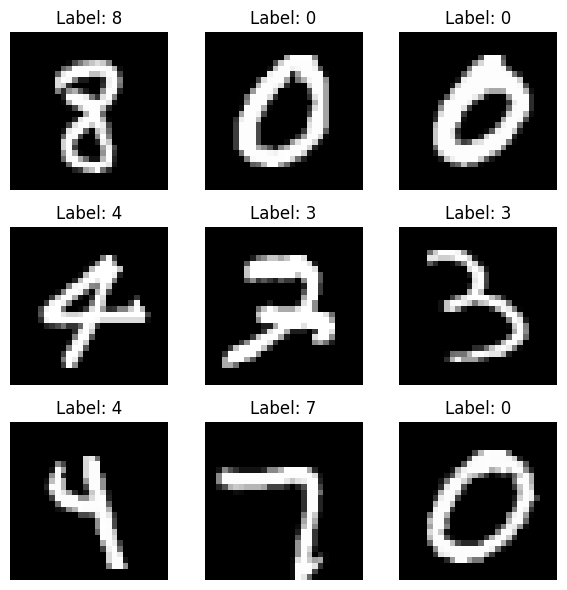

In [66]:
# Create a 3x3 grid of subplots
fig, axes = plt.subplots(3, 3, figsize=(6, 6))
axes = axes.flatten()  # Flatten the 2D array of axes for easy looping

for i in range(9):
    # Pick a random index from the training set
    idx = rng.integers(0, x_train.shape[0])
    
    # 1. Reshape the flat 784 pixels back into a 28x28 image
    img = x_train[idx].reshape(28, 28)
    
    # 2. Plot the image (cmap='gray' shows it in black and white)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Label: {y_train[idx]}")
    axes[i].axis('off')  # Hide pixel coordinate axes

plt.tight_layout()
plt.show()
